## Phase 2: Vector Database Creation & Dual-Model Embedding

## Pipeline Position
```
[Notebook 1 — Data Gathering]
        ↓  data/base_chunked_marriage_laws/*.json
[Notebook 2 — DB Creation]  ◄── YOU ARE HERE
        ↓  database/qdrant_db/  (collections: legal_acts_baseline, legal_acts_jina)
[Notebook 3 — Rechunking]   adds rechunked collections to the same database
```

## What this notebook does

This notebook represents the **Data Ingestion and Vectorization** phase of the Capstone Project.

### Why two embedding models?
To rigorously evaluate our RAG pipeline, we use a **Dual-Model Embedding Strategy**:

| Model | Dimensions | Max Tokens | Role |
|-------|-----------|-----------|------|
| `all-MiniLM-L6-v2` (Baseline) | 384 | 512 | Lightweight industry-standard reference point |
| `jina-embeddings-v3` (Advanced) | 1024 | 8 192 | State-of-the-art, task-specific, large-context model |

By embedding the same legal corpus through both models into separate **Qdrant** collections, we can directly compare retrieval quality in Notebooks 5–7 without any confounding variables.

### What is Qdrant?
Qdrant is an open-source **vector database** stored locally under `database/qdrant_db/`. It stores embedding vectors alongside metadata (payload) and supports fast approximate nearest-neighbour search — the core mechanism behind semantic retrieval in our RAG pipeline.

## Environment Setup & Dependencies
Install the required libraries for vector databases, embedding models, and data manipulation.

In [1]:
import os
# Suppress TensorFlow C++ logging warnings for a cleaner output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Library Imports & Directory Initialization
We establish dynamic paths to ensure the notebook runs smoothly regardless of the local machine's exact directory structure.

In [3]:
import json
import os
from dotenv import load_dotenv
from tqdm import tqdm
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from pathlib import Path
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Determine the base directory dynamically (handles execution from both root and 'notebooks' folders)
try:
    BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    DATA_DIR = BASE_DIR / 'data'
    PROCESSED_DATA_DIR = DATA_DIR / 'processed_data'
    CHUNKED_DATA_DIR = DATA_DIR / 'base_chunked_marriage_laws'  # JSON files from Notebook 1
    DATABASE_DIR = BASE_DIR / 'database'                        # Qdrant persistent storage

    DATABASE_DIR.mkdir(exist_ok=True)
    load_dotenv(BASE_DIR / '.env')

except Exception as e:
    print(f"Missing the required directory or file: {e}")

In [4]:
# !pip install seaborn

## Loading the Pre-Processed Legal Corpus
We aggregate all the chunked JSON files generated during the Data Gathering phase into a single master list for embedding.

In [5]:
all_legal_data = []

# Iterate through the directory and load all chunked legal documents
for filename in os.listdir(CHUNKED_DATA_DIR):
    if filename.endswith(".json"):
        filepath = os.path.join(CHUNKED_DATA_DIR, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)['chunks']
            all_legal_data.extend(data)

print(f"Successfully loaded {len(all_legal_data)} total legal sections from all files.")

with open(PROCESSED_DATA_DIR / "chunked_laws.json", "w") as f:
    json.dump(all_legal_data, f)

print(f"Saved all chunked legal sections to {(PROCESSED_DATA_DIR / 'chunked_laws.json').relative_to(BASE_DIR)}")

# Extract just the text content for the embedding models
docs_to_embed = [item.get('content', '') for item in all_legal_data]

Successfully loaded 782 total legal sections from all files.
Saved all chunked legal sections to data\processed_data\chunked_laws.json


## Model Initialization
We are importing the models from HuggingFace.

In [6]:
# Load API tokens from .env (loaded above via load_dotenv)
hf_token = os.getenv("HUGGINGFACE_API_KEY", "")

## Loading Local Embedding Models
We load both models into local memory. Strict sequence lengths are enforced to control processing limits and ensure a fair baseline vs. advanced model comparison.

In [7]:
# Load Models with Token Limits (GPU-Enabled)
baseline_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
baseline_model.max_seq_length = 512
baseline_model.to(device).eval()

jina_model = SentenceTransformer("jinaai/jina-embeddings-v3", trust_remote_code=True)
jina_model.max_seq_length = 1024
jina_model.to(device).eval()

print(f"Both models loaded on {device}")


A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- configuration_xlm_roberta.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- mlp.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


rotary.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- rotary.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- mha.py
- rotary.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- embedding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- stochastic_depth

Both models loaded on cpu


## Exploratory Data Analysis (Chunk Distribution)
We visualize the distribution of legal section lengths to understand the shape of our corpus. This helps justify chunking strategies and token-limit decisions for our embedding models.

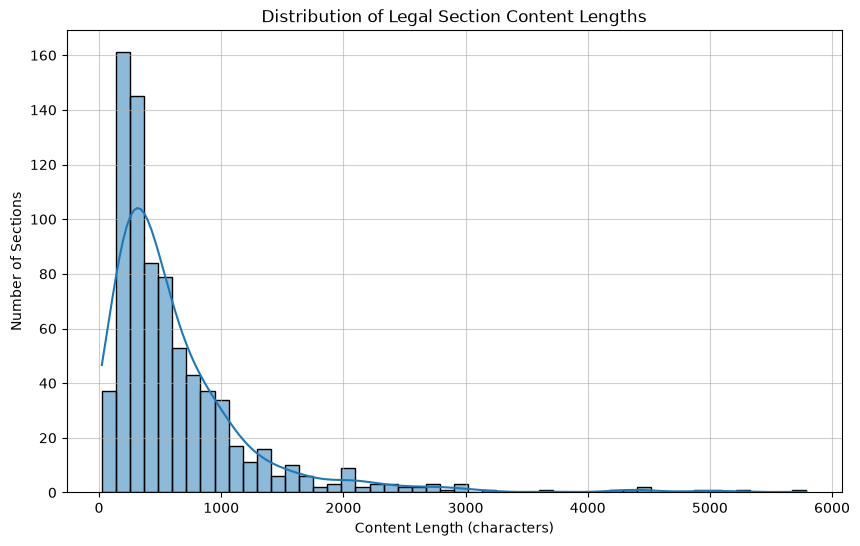

In [8]:
# Extract the lengths of the 'content' field in characters
content_lengths = [len(item.get('content', '')) for item in all_legal_data]

# Create a KDE histogram using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(content_lengths, bins=50, kde=True)
plt.title('Distribution of Legal Section Content Lengths')
plt.xlabel('Content Length (characters)')
plt.ylabel('Number of Sections')
plt.grid(True, alpha=0.6)
plt.show()

> **Observations**:

**The "Long Tail" of Legal Text**

* **Most Laws are Short:** The vast majority of legal sections fall between 200–600 characters, meaning ~90% of the dataset easily fits into a standard 512-token embedding window. 
* **The Truncation Risk:** The distribution has a heavy "long tail" extending up to 6,000 characters. These massive outlier sections contain the most complex and caveat-heavy legal rules.

## Qdrant Vector Database Initialization
We instantiate a local instance of Qdrant and create two isolated collections. Each collection is precisely configured to match the mathematical output dimensions of its respective embedding model (512 for MiniLM, 1024 for Jina).

> Collection **legal_acts_baseline** for Baseline Embeddings with 512 tokens.

> Collection **legal_acts_jina** for Jina Embeddings with 1024 tokens.

In [9]:
print("Initializing Dual Qdrant Collections...")

# Connect to database using dynamically resolved path (creates if not exists)
QDRANT_DB_PATH = DATABASE_DIR / "qdrant_db"
qdrant_client = QdrantClient(path=str(QDRANT_DB_PATH))

# 1. Setup Baseline Collection (384 dimensions)
COLLECTION_BASELINE = "legal_acts_baseline"
if not qdrant_client.collection_exists(COLLECTION_BASELINE):
    qdrant_client.create_collection(
        collection_name=COLLECTION_BASELINE,
        vectors_config=VectorParams(size=baseline_model.get_sentence_embedding_dimension(), distance=Distance.COSINE),
    )

# 2. Setup Jina Collection (1024 dimensions)
COLLECTION_JINA = "legal_acts_jina"
if not qdrant_client.collection_exists(COLLECTION_JINA):
    qdrant_client.create_collection(
        collection_name=COLLECTION_JINA,
        vectors_config=VectorParams(size=jina_model.get_sentence_embedding_dimension(), distance=Distance.COSINE),
    )

Initializing Dual Qdrant Collections...


## Embedding & Upserting Pipeline
We define a modular helper function to vectorize text and construct standard `PointStruct` payloads (including metadata like Act Name and Section). This ensures uniform database ingestion across any model.

In [ ]:
def embed_and_upsert_data(model, docs_to_embed, legal_data, collection_name, task=None):
    '''Embeds documents and upserts them into a Qdrant collection.'''
    
    batch_size = 16  # safer default
    
    for i in tqdm(range(0, len(docs_to_embed), batch_size)):
        docs_batch = docs_to_embed[i:i+batch_size]
        data_batch = legal_data[i:i+batch_size]
        
        with torch.no_grad():
            embeddings = model.encode(
                docs_batch,
                task=task,
                batch_size=batch_size,
                show_progress_bar=False,
                device=device
            )
        
        points = [
            PointStruct(
                id=i + idx,
                vector=vector.tolist(),
                payload={
                    "law_name": item.get('act_number', 'Unknown'),
                    "section_number": item.get('section_number', ''),
                    "section_title": item.get('section_title', ''),
                    "text": item.get('content', '')
                }
            )
            for idx, (item, vector) in enumerate(zip(data_batch, embeddings))
        ]
        
        qdrant_client.upsert(collection_name=collection_name, points=points)
        
        # Delete the embeddings to free GPU memory after each batch
        del embeddings
        torch.cuda.empty_cache()
    
    print(f"Upserted {len(docs_to_embed)} documents to {collection_name}")

## Database Execution
Populate both Qdrant collections by running the ingestion pipeline against the full legal corpus.

In [11]:
# ==========================================
# Dual Database Ingestion: Baseline vs Jina
# ==========================================

# # Embed & Push Baseline Data
embed_and_upsert_data(baseline_model, docs_to_embed, all_legal_data, COLLECTION_BASELINE)

# Embed & Push Jina Data (using 'retrieval.passage' task to optimize for RAG document storage)
embed_and_upsert_data(jina_model, docs_to_embed, all_legal_data, COLLECTION_JINA, task="retrieval.passage")

print("\nBoth models successfully embedded and stored in distinct Qdrant collections!")

100%|██████████| 49/49 [03:19<00:00,  4.07s/it]


Upserted 782 documents to legal_acts_baseline


100%|██████████| 49/49 [1:16:53<00:00, 94.16s/it] 

Upserted 782 documents to legal_acts_jina

Both models successfully embedded and stored in distinct Qdrant collections!


In [12]:
# Close the Qdrant client connection
qdrant_client.close()